In [1]:
from noise import noise_model, bandpass_filter
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import tukey
from scipy.fft import rfft, irfft, rfftfreq
from scipy.signal import welch, butter, filtfilt, savgol_filter, wiener
import pywt

In [38]:
# Load example from file
path = "/n/holystore01/LABS/iaifi_lab/Lab/creissel/neutrino_mass/combined_data_fullsim.hdf5" 
inputs = ['output_ts_I']
cutoff = 4000

arr = {}
with h5py.File(path, 'r') as f:
    for i in inputs:
        arr[i] = f[i][:10]
        arr[i] = arr[i][:, np.newaxis]
        X = np.concatenate([arr[i] for i in inputs], axis = 1)
        X = np.swapaxes(X,1,2)[:,:cutoff, :]

### Visualization

In [69]:
idx = 1
fs = 403e6

sig = X[idx,:,0]
bkg = noise_model(cutoff)

In [70]:
def wavelet_filter(noisy_signal, wavelet='db8'):
    level = pywt.dwt_max_level(len(noisy_signal), pywt.Wavelet(wavelet).dec_len)
    coeffs = pywt.wavedec(noisy_signal, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(noisy_signal)))
    coeffs_thresh = [coeffs[0]]  # Approximation coefficients untouched
    coeffs_thresh += [pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs[1:]]
    denoised_signal = pywt.waverec(coeffs_thresh, wavelet)
    return denoised_signal

In [71]:
#sig = wiener(bandpass_filter(sig), mysize=100)
#bkg = wiener(bandpass_filter(bkg), mysize=100)

#sig = bandpass_filter(sig)
#bkg = bandpass_filter(bkg)

#sig = wavelet_filter(bandpass_filter(sig))
#bkg = wavelet_filter(bandpass_filter(bkg))

#sig = savgol_filter(bandpass_filter(sig), window_length=100, polyorder=3)
#bkg = savgol_filter(bandpass_filter(bkg), window_length=100, polyorder=3)

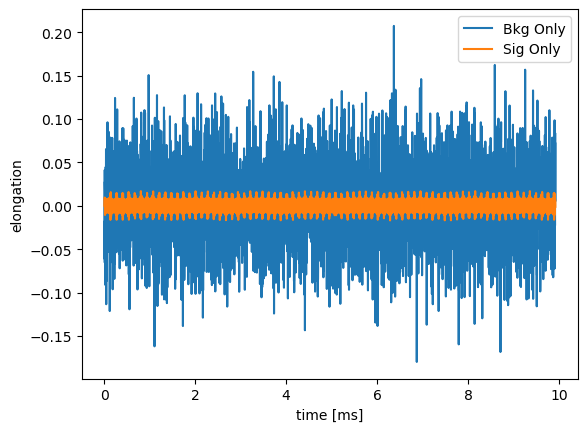

In [72]:
#plt.plot(np.arange(0,4000,1)*1/fs*1e6,sig+bkg, label='Signal+Noise')
plt.plot(np.arange(0,cutoff,1)*1/fs*1e6,bkg, label='Bkg Only')
plt.plot(np.arange(0,cutoff,1)*1/fs*1e6,sig, label='Sig Only')
plt.xlabel('time [ms]')
plt.ylabel('elongation')
#plt.ylim([-0.001,0.001])
plt.legend()
plt.show()

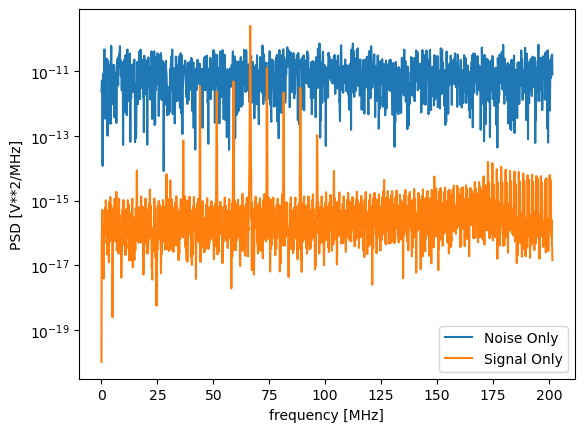

In [73]:
f, psds_bkg = welch(bkg, fs, nperseg=fs)
f, psds_sig = welch(sig, fs, nperseg=fs)
plt.semilogy(f/1e6, psds_bkg, label='Noise Only')
plt.semilogy(f/1e6, psds_sig, label='Signal Only')
#plt.ylim([0.5e-3, 1])
plt.xlabel('frequency [MHz]')
plt.ylabel('PSD [V**2/MHz]')
plt.legend()
plt.show()

In [52]:
def snr(signal, background):
    signal_power = np.mean(signal**2)
    noise_power = np.mean(background**2)
    return signal_power/noise_power

In [45]:
snr(sig,bkg)

np.float64(0.020743843345799266)